# Modelo para predecir el mejor mercado para las PYMES exportadoras.

# *Instalación de paquetes o dependenias.*

In [ ]:
!pip install pandas numpy scikit-learn openpyxl

# *Carga de datos*

Se carga el dataste, previamente elaborado con datos de Trade Map, BCRP y Banco Mundial.

In [ ]:
import pandas as pd
import numpy as np

# --- Cargar cada fuente ---

df_export = pd.read_excel("Datos_compactos_AB.xlsx")

print(df_export.head())
print(df_export.shape)  # cuántas filas y columnas

   hs_code                                           producto pais_destino  \
0  '710812  Oro, incl. el oro platinado, en bruto, para us...       Canada   
1  '710812  Oro, incl. el oro platinado, en bruto, para us...       Canada   
2  '710812  Oro, incl. el oro platinado, en bruto, para us...       Canada   
3  '710812  Oro, incl. el oro platinado, en bruto, para us...       Canada   
4  '710812  Oro, incl. el oro platinado, en bruto, para us...       Canada   

    año  valor_export_usd  valor_import_pais_usd crec_import_pct tipo_cambio  \
0  2020           1904945                4284608               0        3,52   
1  2021           2097305                3985816       -0.069736        3,89   
2  2022           1878249                4190867        0.051445        3,84   
3  2023           2402861                4853993        0.158231        3,74   
4  2024           3044686                5349803        0.102145        3,75   

   pbi_percapita  
0   43537.839299  
1   52886.66

In [ ]:
# --- Estandarizar nombres de columnas ---

df_export.rename(columns={
    "Código HS": "hs_code",
    "Producto": "producto",
    "País destino": "pais_destino",
    "Valor exportado (USD)": "valor_export_usd",
    "Valor importado (USD)": "valor_import_pais_usd",
    "PIB per cápita": "pib_per_capita",
    "Crecimineto Impor%": "crec_import_pct",
    "Tipo de Cambio": "tipo_cambio"

}, inplace=True)

In [ ]:

print(f"Dataset final: {df_export.shape[0]} filas, {df_export.shape[1]} columnas")

Dataset final: 90 filas, 9 columnas


# *Features para el modelo.*

Features creados:

1.   Crecimiento anual de exportaciones peruanas.
2.   Crecimiento de importaciones del país destino
3.   Participación de mercado de Perú.
4.   Volatilidad histórica por producto país.



In [ ]:
# --- Feature 1: Crecimiento anual de exportaciones peruanas ---
# Ordenamos primero para que el cálculo sea cronológico
df = df_export.sort_values(["hs_code", "pais_destino", "año"])

df["crec_export_pct"] = (
    df.groupby(["hs_code", "pais_destino"])["valor_export_usd"]
    .pct_change() * 100
)

# --- Feature 2: Crecimiento de importaciones del país destino ---
# Esto mide qué tan hambrienta está la demanda del otro lado
df["crec_import_pct"] = (
    df.groupby(["hs_code", "pais_destino"])["valor_import_pais_usd"]
    .pct_change() * 100
)

# --- Feature 3: Participación de mercado de Perú ---
# % de las importaciones del país que vienen de Perú
df["part_mercado_pct"] = (
    df["valor_export_usd"] / df["valor_import_pais_usd"]
) * 100

# --- Feature 4: Volatilidad histórica por producto-país ---
# Alta volatilidad = riesgo. Baja = mercado estable.
df["volatilidad"] = (
    df.groupby(["hs_code", "pais_destino"])["crec_export_pct"]
    .transform("std")
)

print(df[["hs_code", "pais_destino", "año",
          "crec_export_pct", "crec_import_pct",
          "part_mercado_pct", "volatilidad"]].head(10))

        hs_code   pais_destino   año  crec_export_pct  crec_import_pct  \
80  '0804400000         España  2020              NaN              NaN   
81  '0804400000         España  2021        31.049630        25.138652   
82  '0804400000         España  2022       -22.818137       -13.972015   
83  '0804400000         España  2023        43.222412        33.809368   
84  '0804400000         España  2024        48.254949        22.569988   
85  '0804400000  Estado Unidos  2020              NaN              NaN   
86  '0804400000  Estado Unidos  2021        16.890279        22.658651   
87  '0804400000  Estado Unidos  2022        20.525640         7.988630   
88  '0804400000  Estado Unidos  2023       -39.866341        -8.312545   
89  '0804400000  Estado Unidos  2024        22.197144        25.067171   

    part_mercado_pct  volatilidad  
80         33.679312    32.639445  
81         35.270169    32.639445  
82         31.643393    32.639445  
83         33.869400    32.639445  
84   

# *RCA, ventaja comparativa real.*

Se halla el RCA, elemento funamental para el proyecto.

In [ ]:
# --- RCA simplificado (Índice de Balassa) ---
#
# Fórmula:
# RCA = (export_producto_pais / export_total_pais)
#       / (export_producto_mundo / export_total_mundo)
#
# RCA > 1 = Perú tiene ventaja comparativa en ese producto
# RCA < 1 = No tiene ventaja comparativa

# Total exportado por Perú por año (todos los productos)
export_total_peru = (
    df.groupby("año")["valor_export_usd"]
    .transform("sum")
)

# Total importado a nivel mundial por año y producto
# (usamos las importaciones de todos los países destino como proxy)
import_total_mundo = (
    df.groupby(["hs_code", "año"])["valor_import_pais_usd"]
    .transform("sum")
)

import_total_global = (
    df.groupby("año")["valor_import_pais_usd"]
    .transform("sum")
)

# Calcular RCA
df["rca"] = (
    (df["valor_export_usd"] / export_total_peru) /
    (import_total_mundo / import_total_global)
)

# Ver los productos con mayor RCA (ventaja comparativa real)
top_rca = (df.groupby(["producto", "pais_destino"])["rca"]
           .mean().sort_values(ascending=False).head(10))
print(top_rca)

producto                                                                  pais_destino 
Arándanos rojos, mirtilos y demás frutos del género "Vaccinium", frescos  Estado Unidos    3.085927
Minerales de cobre y sus concentrados                                     China            1.916254
Uvas frescas                                                              Estado Unidos    1.678811
Arándanos rojos, mirtilos y demás frutos del género "Vaccinium", frescos  Paises Bajos     1.288241
Aguacates "paltas", frescos o secos                                       Paises Bajos     0.568320
Cobre refinado en forma de cátodos y de secciones de cátodos              China            0.526004
Uvas frescas                                                              Paises Bajos     0.474784
Arándanos rojos, mirtilos y demás frutos del género "Vaccinium", frescos  Hong Kong        0.365148
Aguacates "paltas", frescos o secos                                       Estado Unidos    0.325182
            

# *Score de oportunidad, la pieza final.*

Se crea el "Score de oportunidad" el cual asigna pesos a los 4 componentes ejes, de esto saldra un ranking de mercados.

In [ ]:
# --- Score de oportunidad (variable objetivo) ---
#
# Combinamos 4 señales en un índice de 0 a 100:
# 1. Crecimiento de la demanda en el país destino (peso 35%)
# 2. RCA de Perú en ese producto (peso 30%)
# 3. Crecimiento de exportaciones peruanas (peso 20%)
# 4. Baja volatilidad = estabilidad (peso 15%)

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Normalizar cada variable a escala 0-1
variables = ["crec_import_pct", "rca",
             "crec_export_pct", "volatilidad"]

df_clean = df[variables].dropna()
df_norm = pd.DataFrame(
    scaler.fit_transform(df_clean),
    columns=variables,
    index=df_clean.index
)

# La volatilidad la invertimos: menos volatilidad = mejor score
df_norm["estabilidad"] = 1 - df_norm["volatilidad"]

# Score ponderado (suma de pesos = 1.0)
df.loc[df_norm.index, "score_oportunidad"] = (
    df_norm["crec_import_pct"]  * 0.35 +
    df_norm["rca"]               * 0.30 +
    df_norm["crec_export_pct"]  * 0.20 +
    df_norm["estabilidad"]      * 0.15
) * 100  # llevamos a escala 0-100

# Ranking final de oportunidades
ranking = (df.groupby(["producto", "pais_destino"])
           ["score_oportunidad"].mean()
           .sort_values(ascending=False)
           .reset_index())

print(ranking.head(10))

                                            producto   pais_destino  \
0  Arándanos rojos, mirtilos y demás frutos del g...  Estado Unidos   
1              Minerales de cobre y sus concentrados          China   
2                                       Uvas frescas  Estado Unidos   
3  Arándanos rojos, mirtilos y demás frutos del g...   Paises Bajos   
4                                       Uvas frescas         Mexico   
5  Cobre refinado en forma de cátodos y de seccio...          China   
6                Aguacates "paltas", frescos o secos   Paises Bajos   
7  Oro, incl. el oro platinado, en bruto, para us...          India   
8              Minerales de cobre y sus concentrados          Japon   
9                Aguacates "paltas", frescos o secos         España   

   score_oportunidad  
0          58.459275  
1          45.573803  
2          42.801731  
3          39.906631  
4          32.390422  
5          31.753461  
6          30.980736  
7          30.179202  
8          

Se llega al dataset complpeto, donde estan las nuevas variables con sus respectivos pesos. Ahora toca preparar y entrenar el modelo.

In [ ]:
# --- Guardar el dataset final ---

columnas_finales = [
    "hs_code", "producto", "pais_destino", "año",
    "valor_export_usd", "valor_import_pais_usd",
    "crec_export_pct", "crec_import_pct",
    "part_mercado_pct", "volatilidad",
    "rca", "tipo_cambio", "pbi_percapita",
    "score_oportunidad"
]

df_final = df[columnas_finales].dropna(subset=["score_oportunidad"])

# Guardar como CSV (para Python/Power BI)
df_final.to_csv("dataset_exportaciones_limpio.csv", index=False)

# También guardar como Excel (para compartir o revisar)
df_final.to_excel("dataset_exportaciones_limpio.xlsx", index=False)

print(f"Dataset guardado: {df_final.shape[0]} filas listas para el modelo")
print("\nResumen del score de oportunidad:")
print(df_final["score_oportunidad"].describe())

# Vista previa del ranking
print("\nTop 5 oportunidades de exportacion:")
print(df_final.groupby(["producto","pais_destino"])
      ["score_oportunidad"].mean()
      .sort_values(ascending=False).head())

Dataset guardado: 72 filas listas para el modelo

Resumen del score de oportunidad:
count    72.000000
mean     32.313191
std      12.164276
min       8.513726
25%      23.961273
50%      31.290063
75%      38.455969
max      61.569087
Name: score_oportunidad, dtype: float64

Top 5 oportunidades de exportacion:
producto                                                                  pais_destino 
Arándanos rojos, mirtilos y demás frutos del género "Vaccinium", frescos  Estado Unidos    58.459275
Minerales de cobre y sus concentrados                                     China            45.573803
Uvas frescas                                                              Estado Unidos    42.801731
Arándanos rojos, mirtilos y demás frutos del género "Vaccinium", frescos  Paises Bajos     39.906631
Uvas frescas                                                              Mexico           32.390422
Name: score_oportunidad, dtype: float64


# RandomForest

Modelo de ML para predecir el mejor mercado, en base al score de oportunidad.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Cargar el dataset limpio que generamos antes
df = pd.read_csv("dataset_exportaciones_limpio.csv")

# X = las variables que el modelo usa para aprender (features)
features = [
    "rca",               # ventaja comparativa de Perú
    "crec_import_pct",   # crecimiento de demanda en destino
    "crec_export_pct",   # crecimiento histórico de Perú
    "part_mercado_pct",  # participación de mercado actual
    "volatilidad",       # estabilidad del mercado
    "tipo_cambio",       # contexto macro Peru
    "pbi_percapita"      # poder adquisitivo del país destino
]

X = df[features]
y = df["score_oportunidad"]  # lo que queremos predecir

print(f"X: {X.shape} — y: {y.shape}")
print(f"Score promedio en el dataset: {y.mean():.1f}")

X: (72, 7) — y: (72,)
Score promedio en el dataset: 32.3


Se asigna el porcentaje de datos para entrenar y testear (80/20).

In [ ]:
# Dividir: 80% para entrenar, 20% para testear
# random_state=42 asegura que la división sea siempre igual
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print(f"Filas para entrenar: {X_train.shape[0]}")
print(f"Filas para testear:  {X_test.shape[0]}")

Filas para entrenar: 57
Filas para testear:  15


Se empieza a crear el modelo.

In [ ]:
# Crear el modelo con sus parámetros
modelo = RandomForestRegressor(
    n_estimators=100,    # 100 árboles en el bosque
    max_depth=6,         # profundidad máxima de cada árbol
    min_samples_leaf=3,  # mínimo 3 datos por hoja (evita sobreajuste)
    random_state=42      # reproducibilidad
)

# Entrenar: el modelo analiza X_train y aprende a predecir y_train
modelo.fit(X_train, y_train)

print("Modelo entrenado correctamente.")
print(f"Árboles en el bosque: {modelo.n_estimators}")

Modelo entrenado correctamente.
Árboles en el bosque: 100


Se usan los datos de testeo.

In [ ]:
# Hacer predicciones sobre el conjunto de test
y_pred = modelo.predict(X_test)

# Métrica 1: Error Absoluto Medio (MAE)
# "En promedio, el modelo se equivoca por X puntos de score"
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae:.1f} puntos")

# Métrica 2: R² (coeficiente de determinación)
# 0 = el modelo no aprendió nada
# 1 = el modelo predice perfectamente
r2 = r2_score(y_test, y_pred)
print(f"R²: {r2:.3f}")

# Ver predicciones vs valores reales (primeras 10 filas)
comparacion = pd.DataFrame({
    "real": y_test.values[:10],
    "predicho": y_pred[:10].round(1),
    "error": abs(y_test.values[:10] - y_pred[:10]).round(1)
})
print(comparacion)

MAE: 2.8 puntos
R²: 0.637
        real  predicho  error
0  31.379087      33.1    1.7
1  29.261943      26.1    3.1
2  42.120814      40.0    2.2
3  32.452337      34.9    2.4
4  38.286412      39.7    1.4
5  31.201038      31.4    0.2
6  33.206774      32.4    0.8
7  36.369516      39.9    3.5
8  39.923690      41.8    1.9
9  22.489670      30.7    8.2


           variable  importancia
0               rca     0.504205
1   crec_import_pct     0.276738
2   crec_export_pct     0.126233
4       volatilidad     0.068269
3  part_mercado_pct     0.011333
6     pbi_percapita     0.008790
5       tipo_cambio     0.004432


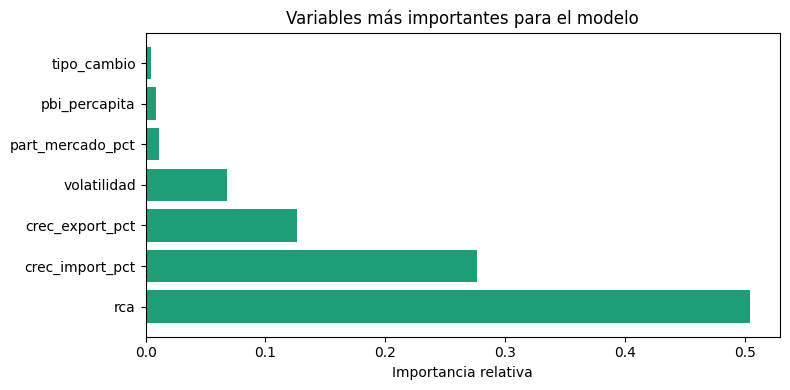

In [ ]:
# Importancia de cada variable en las predicciones
importancias = pd.DataFrame({
    "variable": features,
    "importancia": modelo.feature_importances_
}).sort_values("importancia", ascending=False)

print(importancias)

# Visualizar como gráfico de barras
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.barh(
    importancias["variable"],
    importancias["importancia"],
    color="#1D9E75"
)
plt.xlabel("Importancia relativa")
plt.title("Variables más importantes para el modelo")
plt.tight_layout()
plt.savefig("importancia_variables.png", dpi=150)
plt.show()

# Ranking Final

Ahora se usan todos los datos para entrenar.

In [ ]:
# Predecir el score para TODOS los datos (no solo el test)
df["score_predicho"] = modelo.predict(X)

# Ranking por promedio de los últimos años
ranking = (
    df[df["año"] >= 2021]  # usar solo los años más recientes
    .groupby(["producto", "pais_destino"])
    .agg(
        score_promedio=("score_predicho", "mean"),
        rca_promedio=("rca", "mean"),
        crec_demanda=("crec_import_pct", "mean")
    )
    .reset_index()
    .sort_values("score_promedio", ascending=False)
    .round(1)
)

print("\n=== TOP 10 OPORTUNIDADES DE EXPORTACIÓN ===")
print(ranking.head(10).to_string(index=False))

# Guardar ranking para Power BI o presentación
ranking.to_csv("ranking_oportunidades.csv", index=False)
print("\nRanking guardado en ranking_oportunidades.csv")


=== TOP 10 OPORTUNIDADES DE EXPORTACIÓN ===
                                                                    producto  pais_destino  score_promedio  rca_promedio  crec_demanda
    Arándanos rojos, mirtilos y demás frutos del género "Vaccinium", frescos Estado Unidos            53.4           3.0          16.7
                                       Minerales de cobre y sus concentrados         China            44.8           1.9          18.4
                                                                Uvas frescas Estado Unidos            43.8           1.7           8.3
    Arándanos rojos, mirtilos y demás frutos del género "Vaccinium", frescos  Paises Bajos            41.5           1.2          11.7
                                                                Uvas frescas        Mexico            32.6           0.2          19.1
                                         Aguacates "paltas", frescos o secos        España            31.2           0.3          16.9
Oro, incl.

Al final nos arroja un ranking de 10 mercados oportunidad.